#Principal Component Analysis (PCA)

We will discuss PCA from a variance perspective in this notebook.

#Abstract random variables and their realizations

Assume that we have a real-valued random variable $Z$ distributed according to some distribution $P(Z)$.

Typically, access to this abstract entity $Z$ is provided by samples obtained from experiments (or) trials.

Assume that we conduct $n$ such trials and we collect the samples $\{z^1, z^2, \ldots, z^n\}$.

We call such samples as observations or realizations of the random variable $Z$.

#Dataset: A dual perspective

In this background, consider the dataset $\mathcal{D}=\{\mathbf{x}^i\}_{i=1}^{n}$ where each $\mathbf{x}^i \in {\mathbb{R}}^m$ denotes a $m$-dimensional feature vector for the $i$-th sample. (Note the absence of supervision information here.)

We can collect the samples as column vectors in a suitable data matrix in the following form:

$
\mathbf{X}_{\text{data}} = \begin{pmatrix}
                   \uparrow & \uparrow & \ldots & \uparrow \\
                   \mathbf{x}^1 & \mathbf{x}^2 & \ldots & \mathbf{x}^n \\
                   \downarrow & \downarrow & \ldots & \downarrow \\
              \end{pmatrix}
           = \begin{pmatrix}
                   {x}^1_1 & {x}^2_1 & \ldots & {x}^n_1 \\
                   {x}^1_2 & {x}^2_2 & \ldots & {x}^n_2 \\
                   \vdots & \vdots & \ldots & \vdots \\
                   {x}^1_m & {x}^2_m & \ldots & {x}^n_m \\
              \end{pmatrix}_{m \times n}.
$


This type of description of dataset $D$ gives a sample-based perspective.

However we will now consider the feature perspective.

Note that we can write the data matrix equivalently as:

$
\mathbf{X}_{\text{data}} = \begin{pmatrix}
                  \leftarrow & \mathbf{x}_1^\top & \rightarrow \\
                  \leftarrow & \mathbf{x}_2^\top & \rightarrow \\
                   \ldots & \ldots & \ldots \\
                   \leftarrow & \mathbf{x}_m^\top & \rightarrow \\
              \end{pmatrix}.
$

where $j$-th row consists of $n$ measurements corresponding to the $j$-th feature. Note that we use the superscript to denote the sample and subscript to denote the feature (or) attribute.

Now these measurements are collected into:
$
\mathbf{x}_j = \begin{pmatrix}
                x^1_j \\
                x^2_j \\
                x^3_j \\
                \ldots \\
                x^n_j
                \end{pmatrix}.
$


One can assume that these $n$ measurements for $j$-th feature $\mathbf{x}_j$ are realizations (or) observations corresponding to an underlying abstract entity $X_j$.

#Expectation and Covariance

Consider two real-valued random variables $X_1$ and $X_2$. Then the covariance between these two variables is provided by:

$
cov(X_1, X_2) = E[X_1 X_2] - E[X_1] E[X_2],
$

where $E(Z)$ denotes the expectation of a random variable $Z$.

$E(Z)$ is again an abstract entity. The empirical access to this quantity is provided again by samples (or) realizations.

Suppose we have $n$ realizations $\{z^1, z^2, \ldots, z^n\}$, we usually compute the empirical average $\frac{1}{n} \sum_{i=1}^{n} z^i$ as an estimate for the expectation $E[Z]$. (This fact has connections to laws of large numbers, where this empirical estimate is accurate for large enough $n$.)



Using this we can compute the following quantities for the $j$-th feature.

$E[X_j] = \frac{1}{n} \sum_{i=1}^{n} x_j^i$.

$E[X_k X_j] = \frac{1}{n} \sum_{i=1}^{n} x_k^i x_j^i$.

We now make an important assumption now.

$\textbf{Zero-mean Assumption:}$ We assume that the expectation of $X_j$ is zero, that is, $E[X_j]=0$ for every $j \in \{1,2,\ldots,m\}$.

This assumption is typically to center the $j$-th feature to a mean of zero. The assumption also helps in simplifying the computations.

Based on the zero-mean assumption for each feature, we now have:

$cov(X_i, X_j) = E[X_i X_j]$ for every pair of features.

Then an empirical estimate for $cov(X_i, X_j)$ is given by: $\frac{1}{n} \sum_{k=1}^{n} x_i^k x_j^k$.

$\textbf{Note:}$ The estimate of the form $\frac{1}{n-1} \sum_{k=1}^{n} x_i^k x_j^k$ is usually considered for technical reasons. However, we will use the scaling factor as $\frac{1}{n}$ for our discussions.  

Now, recalling that $
\mathbf{x}_j = \begin{pmatrix}
                x^1_j \\
                x^2_j \\
                x^3_j \\
                \ldots \\
                x^n_j
                \end{pmatrix},
$
we have the equivalent empirical estimate for the covariance $cov(X_i, X_j)$ as: $\frac{1}{n}   \mathbf{x}_i^\top \mathbf{x}_j$.  



Now we can compute the empirical estimates for each pair $(i,j) \in \{1,2,\ldots,m\} \times \{1,2,\ldots,m\}$ and collect them into an empirical feature covariance matrix of the following form:

$
\mathbf{C_X} = \frac{1}{n} \begin{pmatrix}
                           \mathbf{x}_1^\top \mathbf{x}_1 & \mathbf{x}_1^\top \mathbf{x}_2 & \ldots &   \mathbf{x}_1^\top \mathbf{x}_m \\
                           \mathbf{x}_2^\top \mathbf{x}_1 & \mathbf{x}_2^\top \mathbf{x}_2 & \ldots &   \mathbf{x}_2^\top \mathbf{x}_m \\
                           \vdots & \vdots & \ldots & \vdots \\
                           \mathbf{x}_m^\top \mathbf{x}_1 & \mathbf{x}_m^\top \mathbf{x}_2 & \ldots &   \mathbf{x}_m^\top \mathbf{x}_m
                          \end{pmatrix}_{m \times m}
$.



$\textbf{Verify:}$ $\mathbf{C_X} = \frac{1}{n} \mathbf{X}\mathbf{X}^\top.$

$\textbf{Note:}$ $\frac{1}{m} \mathbf{X}^\top \mathbf{X}$ is another covariance matrix associated with $\mathbf{X}$, which is the sample covariance matrix.

Now let us check the emprical feature covariance matrices for some simple datasets.

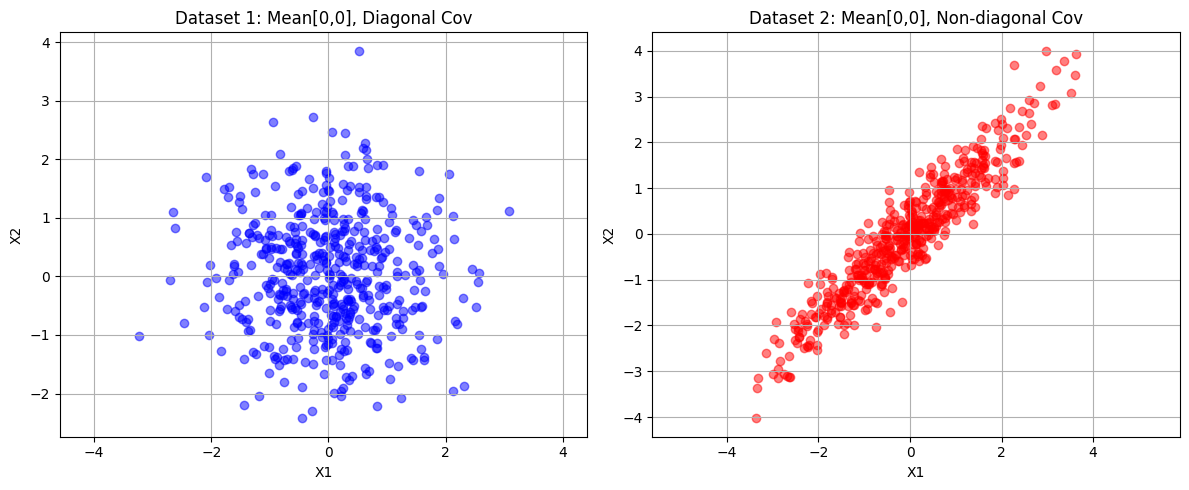

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Set seed for reproducibility
np.random.seed(42)

# --- Cluster 1 ---
# Mean: center, Covariance: diagonal (independent, circular)
mean1 = [0, 0]
cov1 = [[1, 0], [0, 1]]
data1 = np.random.multivariate_normal(mean1, cov1, 500)

# --- Cluster 2 ---
# Mean: same, Covariance: off-diagonal (dependent, elongated/rotated)
mean2 = [0, 0]
cov2 = [[2, 1.9], [1.9, 2]]
data2 = np.random.multivariate_normal(mean2, cov2, 500)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
ax1.scatter(data1[:, 0], data1[:, 1], alpha=0.5, c='blue', label='Dataset D1')
ax1.set_title('Dataset 1: Mean[0,0], Diagonal Cov')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.grid(True)
ax1.axis('equal') # Important for visualizing covariance shape

# Plot 2
ax2.scatter(data2[:, 0], data2[:, 1], alpha=0.5, c='red', label='Dataset D2')
ax2.set_title('Dataset 2: Mean[0,0], Non-diagonal Cov')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.grid(True)
ax2.axis('equal')

plt.tight_layout()
plt.show()

Let us pay specific attention to the covariance matrices of these datasets.

For $D_1$, we have the covariance matrix to be:
$
\begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix}.
$  

For $D_2$, we have the covariance matrix to be:
$
\begin{pmatrix}
2 & 1.9 \\ 1.9 & 2
\end{pmatrix}
$  


For $D_1$ we note that both $X1$ and $X2$ features appear with no particular relation, which is captured by the diagonal covariance matrix.

However for $D_2$, we note that both $X1$ and $X2$ could possibly be related by $X2 = f(X1)$ for some $f$. In such cases, we might want to estimate such relation $f$ and ignore the feature $X2$ altogether from the data modeling. We can use only $X1$ and then recover $X2$ information using $f$. We call such dataset $D_2$ to exhibit high feature redundancy, where the feature $X2$ seems to be redundant.

High feature redundancy is one of the key motivations for dimensionality reduction, where we aim to remove redundant features (or) attributes which show over-dependence on other attributes.

We will consider linear dependencies here. Note that this idea can be taken to non-linear dependencies with suitable modifications.




Let us now check two other datasets.

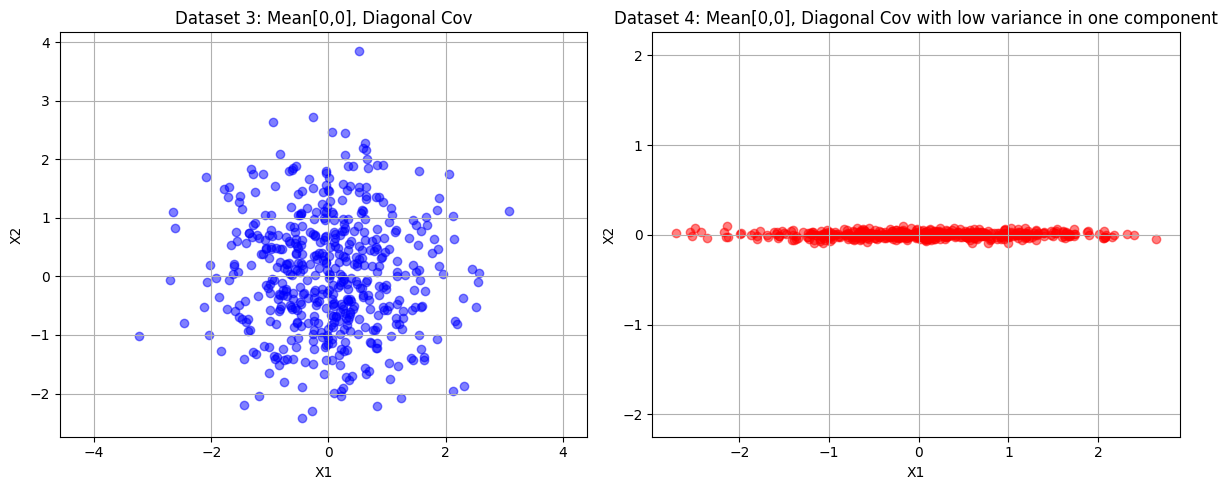

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Set seed for reproducibility
np.random.seed(42)

# --- Cluster 1 ---
# Mean: center, Covariance: diagonal (independent, circular)
mean1 = [0, 0]
cov1 = [[1, 0], [0, 1]]
data1 = np.random.multivariate_normal(mean1, cov1, 500)

# --- Cluster 2 ---
# Mean: different, Covariance: diagonal (independent, circular) but with low variance in one component
mean2 = [0, 0]
cov2 = [[1, 0], [0, 0.001]]
data2 = np.random.multivariate_normal(mean2, cov2, 500)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
ax1.scatter(data1[:, 0], data1[:, 1], alpha=0.5, c='blue', label='Dataset D3')
ax1.set_title('Dataset 3: Mean[0,0], Diagonal Cov')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.grid(True)
ax1.axis('equal') # Important for visualizing covariance shape

# Plot 2
ax2.scatter(data2[:, 0], data2[:, 1], alpha=0.5, c='red', label='Dataset D4')
ax2.set_title('Dataset 4: Mean[0,0], Diagonal Cov with low variance in one component')
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.grid(True)
ax2.axis('equal')

plt.tight_layout()
plt.show()

Here we note that the covariance matrix of dataset $D_3$ is diagonal with both diagonal entries being $1$:
$
\begin{pmatrix}
1 & 0 \\ 0 & 1
\end{pmatrix}.
$

The covariance matrix of dataset $D_4$ is also diagonal, but now the variance of one component $X2$ is set to be very small (close to zero):
$
\begin{pmatrix}
1 & 0 \\ 0 & 0.001
\end{pmatrix}.
$

We note that in this case $X2$ manifests itself as a low-information signal when in fact the entire information is carried by $X1$. We wish to call such feature components as non-informative signal (we will avoid the use of term "noise") and hence we wish to remove such features as well.

Thus our goals are well-defined now:

1. Our feature co-variance matrix should be diagonal.
2. We do not wish to have features with very low variances.

Since the original feature covariance matrix for the data $\mathcal{D}=\{\mathbf{x}^i\}_{i=1}^{n}$ is well-defined, we cannot hope to make this covariance matrix as diagonal directly.

We will use the following idea:
$\textbf{Can we diagonalize the feature covariance matrix?}$.

Diagonalizing a matrix is a popular idea in Matrix Algebra (also in Linear Algebra in general).

We have the following definition.



#Digonalizability of a Matrix

A square matrix $A$ is said to be diagonalizable if there exist a diagonal matrix $D$ and an invertible matrix $B$ such that: $BAB^{-1} = D$.

Such transformation of a non-diagonal matrix $A$ into a diagonal matrix $D$ is called $\textit{similarity transformation}$.

Thus in short, in PCA, we aim to diagonalize the feature covariance matrix using such a transformation such that we get a different diagonal matrix:

${\mathbf{C}}_{\mathbf{Y}} = B {\mathbf{C}}_{\mathbf{X}}B^{-1}$.

If we can use the diagonal matrix to characterize our original data, then we can hope to use it to remove the redundancy and low variance components in our data.

In PCA, we use specific choice for $B$ matrix. We choose $B$ to be an orthogonal matrix.

#Orthogonal matrix:
Consider a matrix
$
Q = \begin{pmatrix}
     \uparrow & \uparrow & \ldots &\uparrow \\
     q_1 & q_2 & \ldots & q_m \\
     \downarrow & \downarrow & \ldots &\downarrow \\
    \end{pmatrix}_{m \times m}.
$

Such a matrix $Q$ is called orthogonal if the following hold:
1. $q_i^\top q_j = 0, \ \forall i,j \in \{1,2,\ldots,m\} \; \text{s.t.} \; i \neq j$,
2. $q_i^\top q_i = 1, \ \forall i \in \{1,2,\ldots,m\}$.

The first property indicates that distinct $q_i$ and $q_j$ are orthogonal vectors.
The second property indicates that each $q_i$ vector has length 1.
Such collection of $\{q_1, q_2, \ldots, q_m\}$ vectors form an othonormal set of vectors.

We will discuss some properties of orthonormal matrices now.

1. The inverse of matrix $Q$ is $Q^{-1} = Q^\top$.
2. The set of column vectors of matrix $Q$ given by $\{q_1, q_2, \ldots, q_m\}$ form an orthonormal basis for the set ${\mathbb{R}}^m$.

The second property might introduce new ideas of "basis". We shall understand what a basis is later on. For now, you can associate an orthonormal basis to the standard basis containing $m$ vectors of the form:

$\left \{ \begin{bmatrix} 1 \\ 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 0 \\ 1 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 0 \\ 0 \\ \vdots \\ 1 \end{bmatrix} \right  \}$ for ${\mathbb{R}}^m$.


Armed with these properties, we aim to have:

${\mathbf{C}}_{\mathbf{Y}} = P {\mathbf{C}}_{\mathbf{X}}P^{-1}$,
where $P$ is an orthonormal matrix.

This can be written as:  
${\mathbf{C}}_{\mathbf{Y}} = P {\mathbf{C}}_{\mathbf{X}}P^{\top}$.

Now assuming ${\mathbf{C}}_{\mathbf{Y}}$ to be $D$ and ${\mathbf{C}}_{\mathbf{X}}$ to be A, we get:

$D = P A P^\top$, which implies:

$P^\top D =  A P^\top$ (since $P^\top$ is the inverse of $P$).

Now notice the structure of this identity:

Assuming the column structure of $P^\top$ to be:
$
P^\top = \begin{pmatrix}
     \uparrow & \uparrow & \ldots &\uparrow \\
     v_1 & v_2 & \ldots & v_m \\
     \downarrow & \downarrow & \ldots &\downarrow \\
    \end{pmatrix}_{m \times m}.
$

and the diagonal matrix $D$ to be:
$
D = \begin{pmatrix}
     d_1 & 0 &  0 & \ldots &0 \\
     0& d_2 &  0 & \ldots &0 \\
     0& 0 & d_3 & \ldots &0 \\
     \vdots & \vdots & \vdots & \ldots & \vdots \\
     0& 0 & 0 & \ldots & d_m \\
    \end{pmatrix}_{m \times m}.
$


We see that the above identity implies:

$
A \begin{pmatrix}
     \uparrow & \uparrow & \ldots &\uparrow \\
     v_1 & v_2 & \ldots & v_m \\
     \downarrow & \downarrow & \ldots &\downarrow \\
    \end{pmatrix} =
     \begin{pmatrix}
     \uparrow & \uparrow & \ldots &\uparrow \\
     v_1 & v_2 & \ldots & v_m \\
     \downarrow & \downarrow & \ldots &\downarrow \\
    \end{pmatrix}
    \begin{pmatrix}
     d_1 & 0 &  0 & \ldots &0 \\
     0& d_2 &  0 & \ldots &0 \\
     0& 0 & d_3 & \ldots &0 \\
     \vdots & \vdots & \vdots & \ldots & \vdots \\
     0& 0 & 0 & \ldots & d_m \\
    \end{pmatrix}.
$

Equating the columns we have:
$
Av_i = d_i v_i,  \ \forall i \in \{1,2,\ldots,m\}.
$

This has resemblance to the eigen-vector and eigen-value relation.


$\textbf{Recall:}$
Consider a $m \times m$ square matrix $A$. A non-zero vector $v \in {\mathbb{R}}^m$ is called an eigen vector of $A$ with a corresponding eigen value $\lambda$ if the following holds: $Av = \lambda v$.

That is, the transformation $A$ applied on $v$ results in scaling and possibly refelection of $v$ ($Av$ is a scaled version of $v$, scaled by $\lambda$ resulting in a scaled vector $\lambda v$ either in the same direction ($\lambda \geq 0$) or as a reflection in the opposite direction ($\lambda < 0$).)


This relation motivates us to construct $P^\top$ and $D$ using linearly independent eigen vectors of $A$, which is ${\mathbf{C}}_{\mathbf{X}}$.

Assuming that we can find $m$ such linearly independent eigen vectors of ${\mathbf{C}}_{\mathbf{X}}$, we can then construct $P^\top$ as the matrix whose columns are these $m$ linearly independent eigen vectors of ${\mathbf{C}}_{\mathbf{X}}$.

This would yield a diagonal matrix whose diagonal elements are the eigen values of ${\mathbf{C}}_{\mathbf{X}}$.

However there are some caveats here explained by the following questions:

1. Can we always find $m$ linearly independent eigen vectors for ${\mathbf{C}}_{\mathbf{X}}$?

2. In case we can collect $k$ linearly independent eigen vectors for ${\mathbf{C}}_{\mathbf{X}}$ where $k \leq m$, can we still construct $P^\top$?

3. Suppose we have linearly independent eigen vectors can we assure that they are orthogonal?

It turns out that we can collect $k$ linearly independent eigen vectors $\{v_1, v_2,\ldots,v_k\}$ corresponding to $k$ distinct eigen values of ${\mathbf{C}}_{\mathbf{X}}$. And we can compose $P^\top$ by collecting additional $m-k$ linearly independent vectors $\{u_1, u_2,\ldots,u_{m-k}\}$ such that the entire set $\{v_1, v_2,\ldots,v_k, u_1, u_2,\ldots,u_{m-k} \}$ is linearly independent.

Also given a set of linearly independent vectors, we can convert them into orthonormal eigen vectors.

However for the set $\{u_1, u_2,\ldots,u_{m-k}\}$, a direct relationship to eigen vector-eigen value connection is lost. It would be interesting to explore this further.






#Exercise

Suppose the data matrix $\mathbf{X}_{m \times n}$ is transformed into a different matrix $\mathbf{Y} = P\mathbf{X}$ using an orthogonal transformation (when $P$ is an orthgonal matrix, we call the transformation $PA$ to be an orthogonal transformation of $A$ using $P$), show that the feature covariance matrix $\mathbf{C}_{\mathbf{Y}} = \frac{1}{n} \mathbf{Y}\mathbf{Y}^\top$ is diagonal.   

Based on the above exercise, we might then see that using a suitable transformation of the original data $\mathbf{X}$, we arrive at a transformed data $\mathbf{Y}$, which has the desirable diagonal matrix property.

Now to discard the low-variance components of the covariance matrix of $\mathbf{Y}$ we can do a thresholding of the diagonal matrix $\mathbf{C}_{\mathbf{Y}}$, and retain only the remaining components.

#Check:
Discarding the low-variance terms of $\mathbf{C}_{\mathbf{Y}}$ can simply be obtained by dropping a few rows of $P$ or columns of $P^\top$.

# Key Takeaways

1. The dataset $\mathcal{D} = \{\mathbf{x}^i\}_{i=1}^{m}$ can be seen as a collection of features $\mathbf{x}_j$, each having $n$ measurements.
2. The data can be composed into an $m\times n$ matrix $\mathbf{X}$ where the $j$-th row represents the $n$ measurements of feature $\mathbf{x}_j$.
3. In PCA, we aim to check if the feature covariance matrix $\mathbf{C}_\mathbf{X} = \frac{1}{n} \mathbf{X}\mathbf{X}^\top$ is in the form of a diagonal matrix.
4. If $\mathbf{C}_\mathbf{X}$ is not a diagonal matrix, then we transform the original data $\mathbf{X}$ into transformed data $\mathbf{Y} = P \mathbf{X}$ using an orthogonal transformation via an orthogonal matrix $P$.
5. Then this new transformed data $\mathbf{Y}$ is shown to have a diagonal feature covariance matrix $\mathbf{C}_\mathbf{Y}$.
6. The rows of $P$ are composed of linearly independent (and orthonormal) eigen vectors of $\mathbf{C}_\mathbf{X}$. They form the principal components of $\mathbf{X}$.
7. To transform the original data $\mathbf{X}_{m \times n}$ to a low-dimensional form, we can choose $k \ll m$ rows of $P$ and get $\mathbf{Y}_{k \times n}$ transformed data. For the transformed data $\mathbf{Y}$, there are only $k \ll m$ features.




A simple algorithm using this idea:

In [ ]:

from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

def print_msg(message, kargs):
  print()
  print(message)
  print(kargs)
  print("*"*20)

# Load iris data
iris = load_iris()

#The actual data is in num_samples x num_feature format
X_data = iris.data
print_msg('Iris data loaded... original shape: ',X_data.shape)

n = X_data.shape[0]
dim = X_data.shape[1]

#We want X to have num_features x num_samples form.
X = X_data.T
print_msg('Feature matrix X shape: ',X_data.shape)

#Compute feature covariance matrix
C_X = 1/n*(X@X.T)

#print_msg('Feature covariance matrix:',C_X)
print_msg("Rank of feature covariance matrix:", np.linalg.matrix_rank(C_X))


# Compute eigenvalues and eigenvectors of feature covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(C_X)

print_msg("C_X Eigenvalues:", eigenvalues)
print_msg("C_X Eigenvectors (column-wise):\n", eigenvectors)
print_msg('C_X eigenvectors shape:', np.shape(eigenvectors))


# checking if we can collect a few linearly independent eigen vectors

import sympy
#the following code tells us the locations of linearly independent columns in a matrix
_, indices = sympy.Matrix(eigenvectors).rref()
print()
print_msg("L.I eig vectors are in indices:", indices)


#Make the eigen vectors orthonormal
from scipy.linalg import orth
orth_eigvectors = orth(eigenvectors)
#print_msg("Orthonormal eigen vectors:",orth_eigvectors)
print_msg("Orthonormal eigen vectors shape:",orth_eigvectors.shape)

#Transform the data as Y=PX where P contains the orthonormal eigen vectors as rows
Y = orth_eigvectors.T @ X
print_msg("Transformed data: Y=PX shape",np.shape(Y))

#Computet he feature covariance matrix of transformed data
C_Y = Y@Y.T/n
print_msg("checking for a diagonal structure of the feature covariance matrix of transformed data:",C_Y)

#Find the indices of C_Y sorted accroding to non-increasing  variances of C_Y
indices = np.flip(np.argsort(np.diag(C_Y)))
sorted_ =  np.flip(np.sort(np.diag(C_Y)))
print_msg("Rows of P sorted according to variances: ", indices)
print_msg("Principal components in sorted order:", sorted_)



Iris data loaded... original shape: 
(150, 4)
********************

Feature matrix X shape: 
(150, 4)
********************

Rank of feature covariance matrix:
4
********************

C_X Eigenvalues:
[6.13887005e+01 2.10302878e+00 7.98536194e-02 2.36838014e-02]
********************

C_X Eigenvectors (column-wise):

[[ 0.75110816  0.2841749   0.50215472  0.32081425]
 [ 0.38008617  0.5467445  -0.67524332 -0.31725607]
 [ 0.51300886 -0.70866455 -0.05916621 -0.48074507]
 [ 0.16790754 -0.34367081 -0.53701625  0.75187165]]
********************

C_X eigenvectors shape:
(4, 4)
********************


L.I eig vectors are in indices:
(0, 1, 2, 3)
********************

Orthonormal eigen vectors shape:
(4, 4)
********************

Transformed data: Y=PX shape
(4, 150)
********************

checking for a diagonal structure of the feature covariance matrix of transformed data:
[[ 5.36708767e-02 -1.78197746e-14 -5.49383453e-02 -2.95543847e-02]
 [-1.78197746e-14  6.13887005e+01  1.16082346e-14  9.5524

Let us now use the principal components to reduce the data dimension


Top Principal components:
[[ 0.71813124 -0.38008617 -0.52058316 -0.26232653]
 [ 0.36031043 -0.51300886  0.71040598  0.31987754]]
********************

PCA Reduced data shape:
(150, 2)
********************


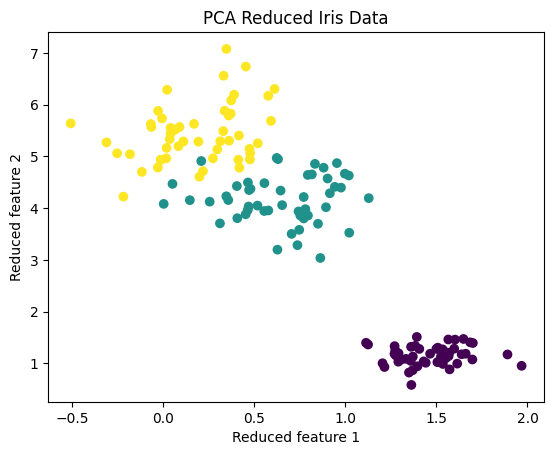

In [ ]:
#Let us take the first two principal components and then reduce the dimension of the data and plot
import matplotlib.pyplot as plt
P = orth_eigvectors[indices[0:2],:]
print_msg("Top Principal components:",P)
X_reduced = (P @ X).T
print_msg("PCA Reduced data shape:", X_reduced.shape)


plt.scatter(X_reduced[:,0], X_reduced[:,1], c=iris.target, cmap='viridis')
plt.xlabel('Reduced feature 1')
plt.ylabel('Reduced feature 2')
plt.title('PCA Reduced Iris Data')
plt.show()

#Appendix

$\Large\textbf{Idea of linear independence and basis}$

Before we get into these notions, it might be useful to recall the idea of a vector space.

Consider a vector space ${\mathbb{R}}^m$ over the set of reals $\mathbb{R}$.

Recall that a vector space $V$ (over a field $F$) is defined as a set of elements endowed the following two operations:

1. an addition operation to add two elements of $V$ (elements of $V$ are typically called vectors)
2. a scalar multiplication operation to multiply the element of $V$ using an element of $F$ (elements of $F$ typically called a scalar).

To get a sense of how the addition operation behaves, you can always think about the nature of addition in $\mathbb{R}^m$.

Similarly, to get an idea of how the scalar multiplication operation behaves, you can think about the nature of scalar multiplication of elements in $\mathbb{R}^m$ using scalars from $\mathbb{R}$.

Hence we made a conscious choice of these two sets $\mathbb{R}^m$, $\mathbb{R}$ as our $V$ and $F$ respectively.

##Linear combination of a set of vectors

Consider a vector space ${\mathbb{R}}^m$ over the set of reals $\mathbb{R}$.

Consider a set $S=\{v_1, v_2, \ldots, v_k\}$ of vectors from ${\mathbb{R}}^m$. Then the quantity:

$
\alpha_1 v_1 + \alpha_2 v_2 + \ldots + \alpha_k v_k
$

is called a linear combination of the vectors $v_1, v_2, \ldots, v_k$ where the combination is established using the scalars $\alpha_1, \alpha_2, \ldots, \alpha_k \in \mathbb{R}$.

## Linear Independence

Consider a vector space ${\mathbb{R}}^m$ over the set of reals $\mathbb{R}$.

Consider a set $S=\{v_1, v_2, \ldots, v_k\}$ of vectors from ${\mathbb{R}}^m$.

If
$
\alpha_1 v_1 + \alpha_2 v_2 + \ldots + \alpha_k v_k = \mathbf{0}
$

implies $\alpha_1 = \alpha_2 = \ldots = \alpha_k = 0$,

then we call the set $S$ to be linearly independent.

That is, for linearly independent vectors $v_1, v_2, \ldots, v_k$, it happens that whenever a linear combination of these vectors results in zero vector, then the coefficients $\alpha_1, \alpha_2, \ldots, \alpha_k$ are necessarily zero.


## Exercise

Show that the columns $q_1, q_2, \ldots, q_m$ of the orthogonal matrix $Q$ introduced above are linearly independent.


## Basis

Consider a vector space ${\mathbb{R}}^m$ over the set of reals $\mathbb{R}$.

Consider a set $S=\{v_1, v_2, \ldots, v_k\}$ of vectors from ${\mathbb{R}}^m$.

Then the set $S$ is called a basis if:

1. Every vector of ${\mathbb{R}}^m$ can be written as a linear combination of the vectors in set $S$
2. Every vector of ${\mathbb{R}}^m$ can be written as a unique linear combination of the vectors in set $S$.

   That is if $u \in \mathbb{R}^m$, then $u = \beta_1 v_1 + \beta_2 v_2 + \ldots + \beta_k v_k$.

   Further if $u = \eta_1 v_1 + \eta_2 v_2 + \ldots + \eta_k v_k$, then $\eta_1=\beta_1, \eta_2 = \beta_2, \ldots, \eta_k = \beta_k$.

## Exercise

For the standard basis $\mathcal{B} = \left \{ \begin{bmatrix} 1 \\ 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 1 \\ 0 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 0 \\ 1 \\ \vdots \\ 0 \end{bmatrix}, \begin{bmatrix} 0 \\ 0 \\ 0 \\ \vdots \\ 1 \end{bmatrix} \right  \}$ for ${\mathbb{R}}^m$.
discussed above, show that every element of $\mathbb{R}^m$ can be written as a unique linear combination of elements of $\mathcal{B}$.


## An interesting property

Consider the vector space $\mathbb{R}^m$ over $\mathbb{R}$.

If a set $S$ consists of exactly $m$ linearly independent vectors, then $S$ forms a basis for $\mathbb{R}^m$.

## Check
Based on this property check if the set of column vectors $\{q_1, q_2, \ldots, q_m\}$ of the orthogonal matrix $Q$ form a basis for $\mathbb{R}^m$.

## Orthonormal Basis

If a set of orthonormal vectors form a basis for a $\mathbb{R}^m$ over $\mathbb{R}$, then the set is called an orthonormal basis.   

## An immediate result:

Based on this fact, note that the set of column vectors $\{q_1, q_2, \ldots, q_m\}$ of the orthogonal matrix $Q$ form an orthonormal basis for $\mathbb{R}^m$.

#References

The primary reference for this notebook is the following popular tutorial on PCA:

[1] Jonathan Shlens, A Tutorial on Principal Component Analysis. https://arxiv.org/abs/1404.1100

Other treatments are available in most ML text books like Chris Bishop's PRML Book.